In [1]:
import torch

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [3]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

In [4]:
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

In [ ]:
# net = models.SimpleSRNN(
#     n_in=input_dim,
#     ns_hidden=[256, 256],
#     n_out=len(classes),
#     beta=0.9,
# ).to(device)

net = models.SimpleSNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.03630514705882353


Epoch 0:   2%|▏         | 1/63 [00:00<00:29,  2.13it/s, acc=3.91%, loss=3.00]

Epoch 0, Iteration 0 — Loss: 3.00, Acc: 3.91%


Epoch 0:  41%|████▏     | 26/63 [00:13<00:18,  2.04it/s, acc=3.91%, loss=3.04] 

Epoch 0, Iteration 25 — Loss: 3.04, Acc: 3.91%


...

Epoch 9, Iteration 25 — Loss: 2.99, Acc: 8.59%


Epoch 9:  81%|████████  | 51/63 [00:42<00:09,  1.32it/s, acc=8.59%, loss=3.01] 

Epoch 9, Iteration 50 — Loss: 3.01, Acc: 8.59%


Epoch 9: 100%|██████████| 63/63 [00:51<00:00,  1.22it/s, acc=7.81%, loss=3.00] 


Test Accuracy after training is: 0.0739889705882353


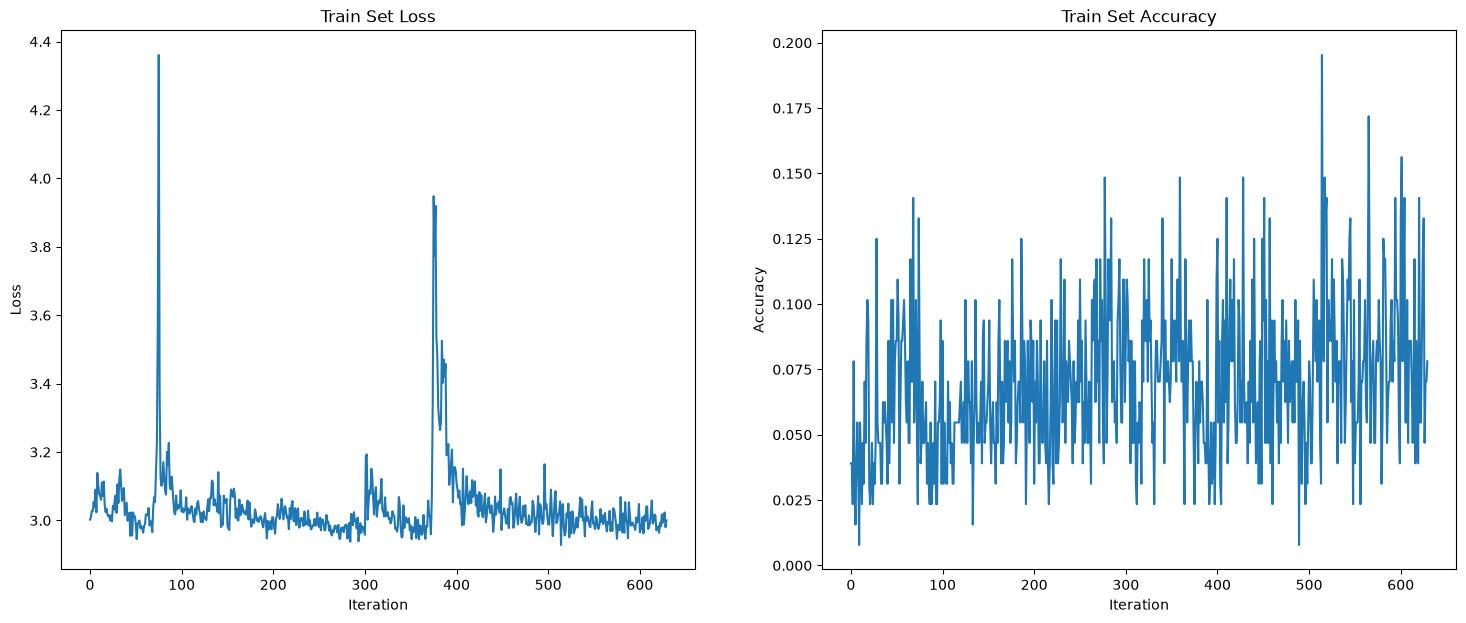

In [5]:
net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")